Estimated carrying capacity of goats: 52,804,624


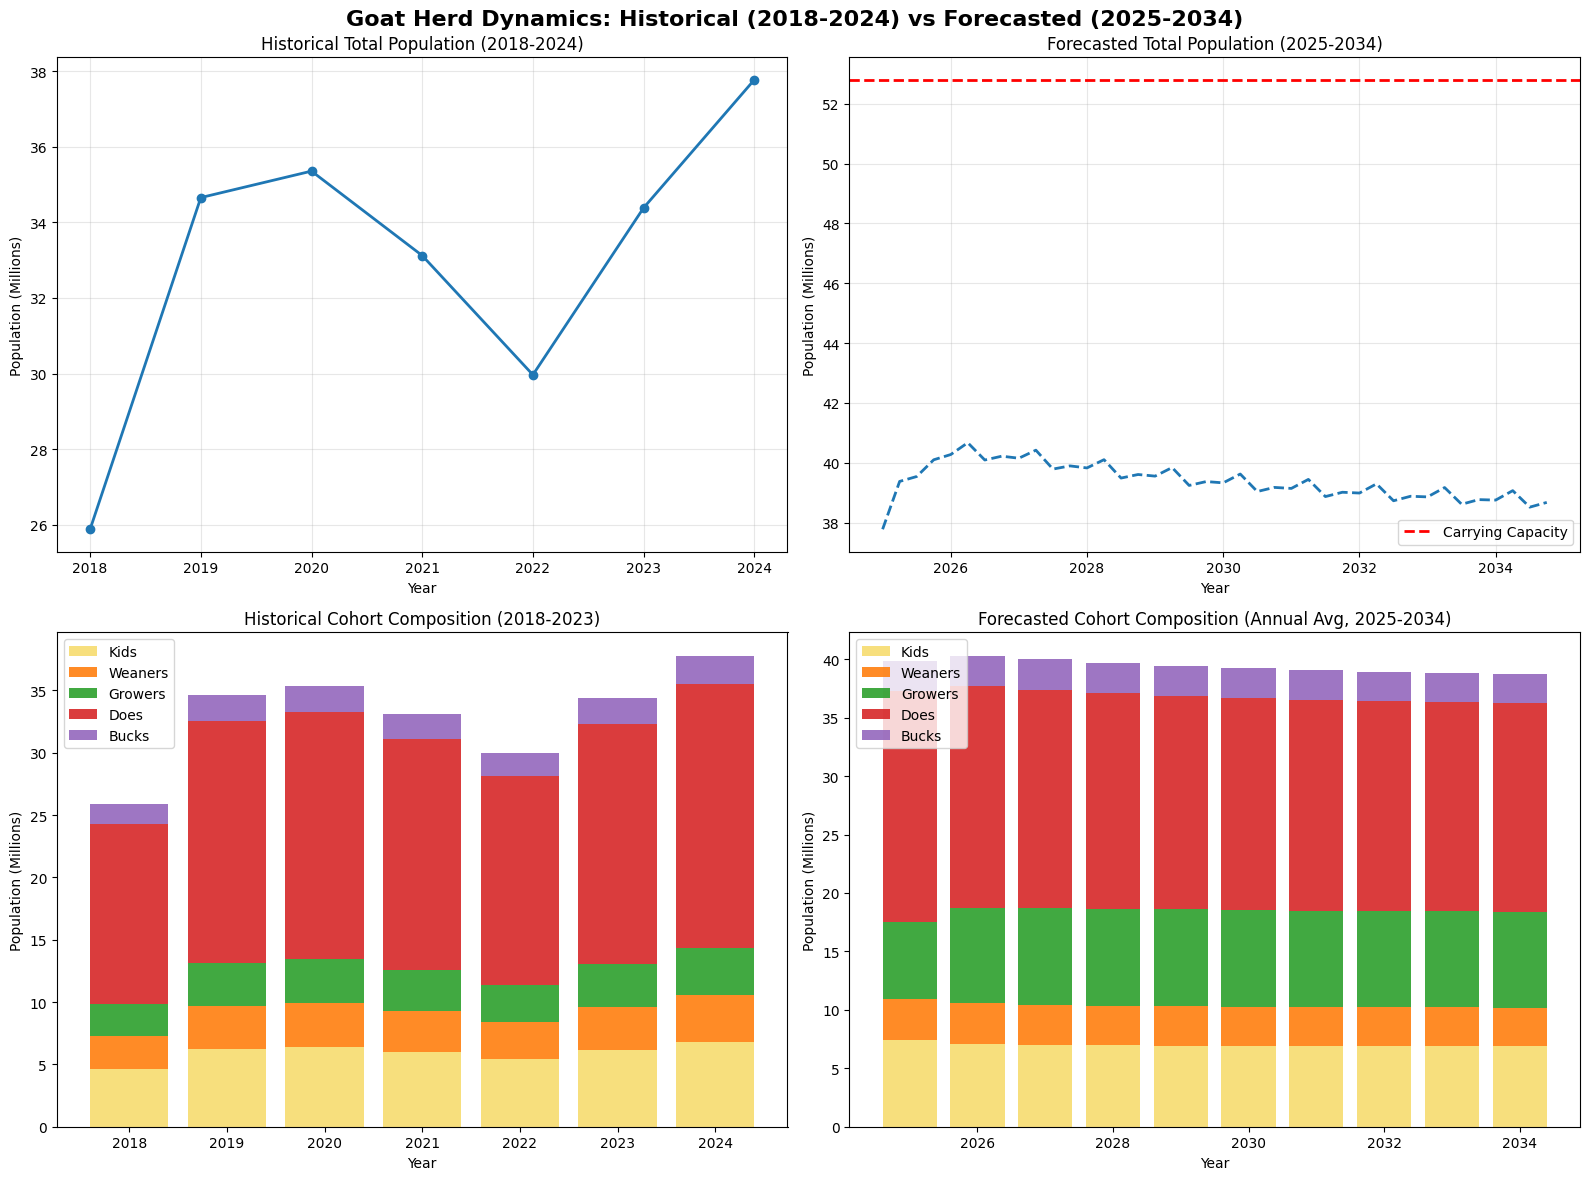

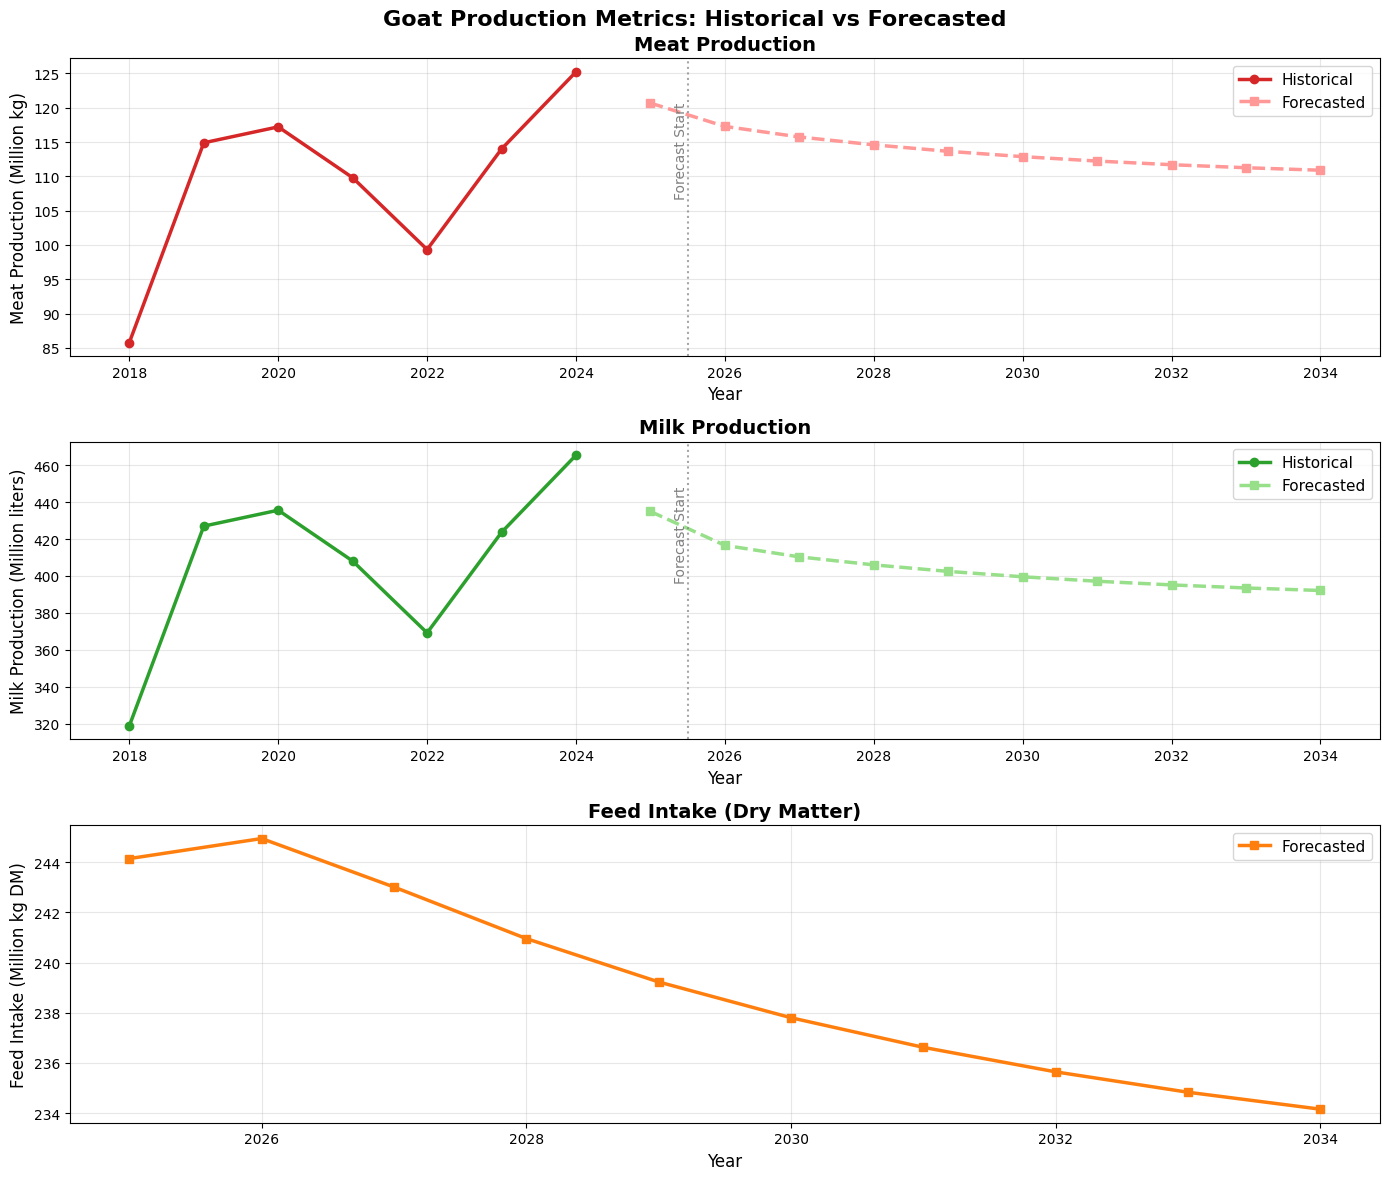

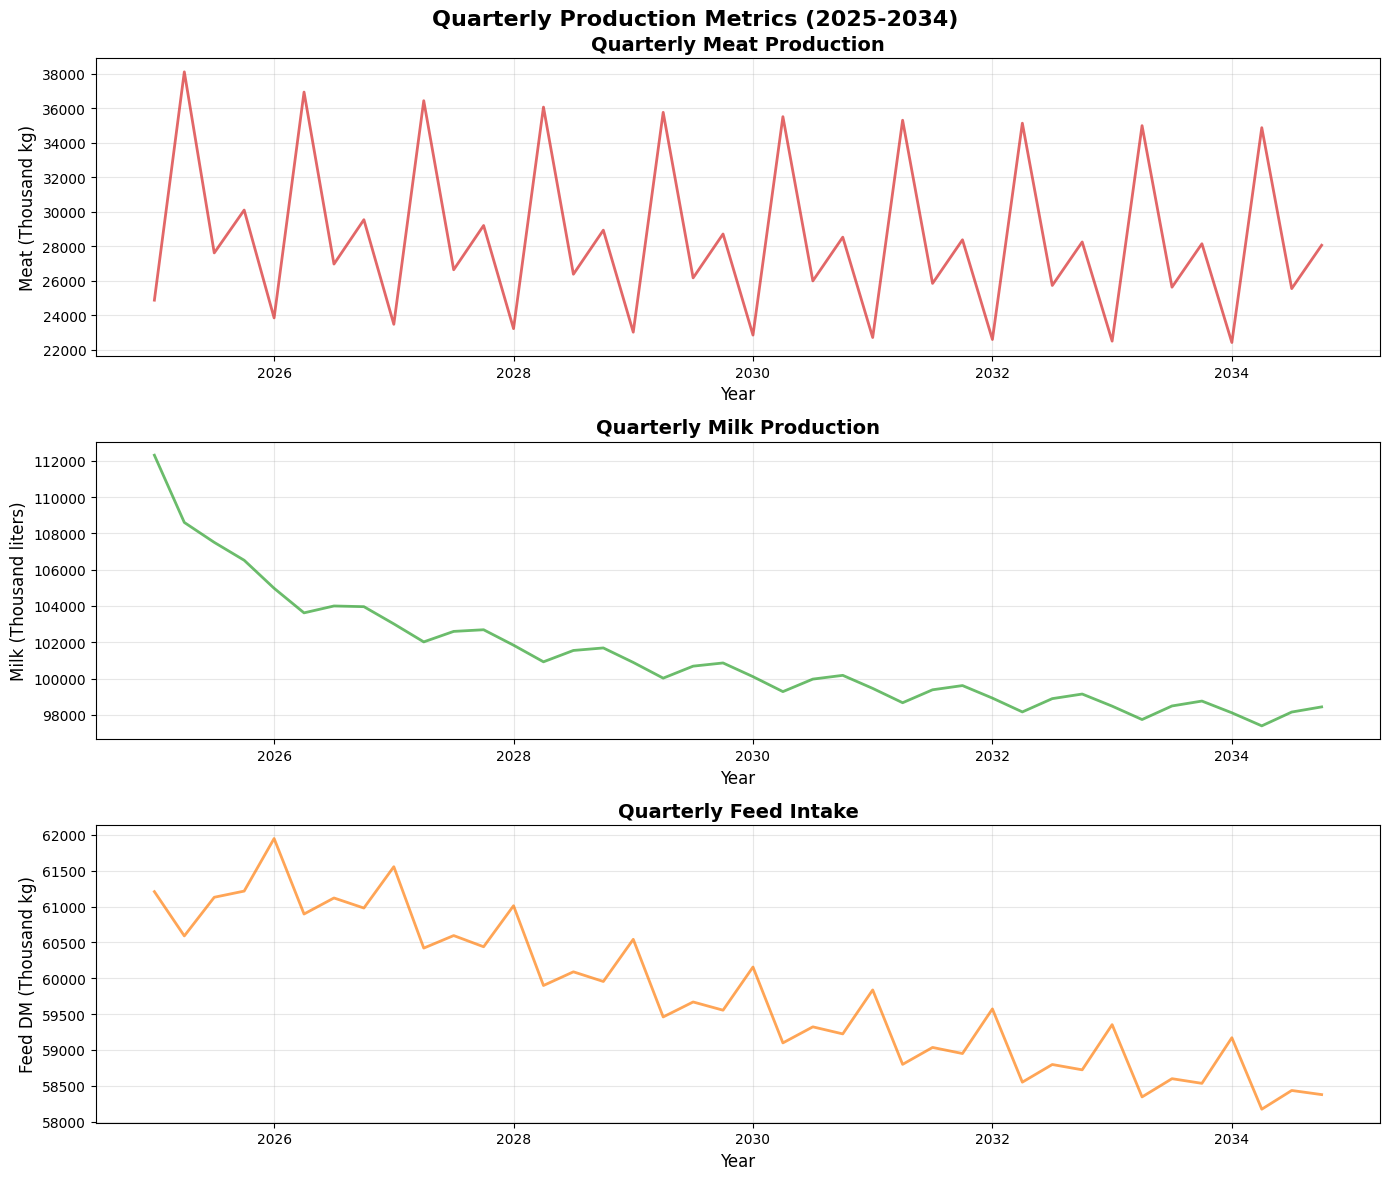

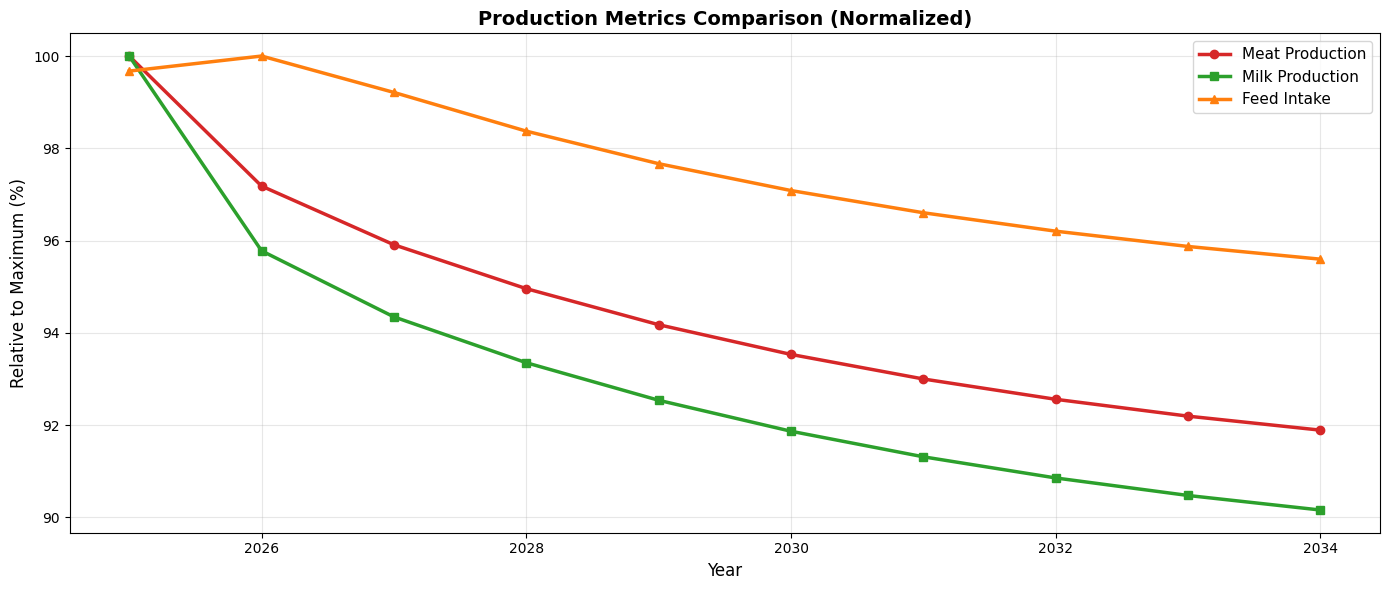

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ============================================================================
# SETTINGS / CONSTANTS (UPDATED)
# ============================================================================

def weighted_land_requirement(zones):
    return sum(zone['proportion'] * zone['land_per_goat'] for zone in zones)

def carrying_capacity(total_land_ha, land_per_goat):
    return total_land_ha / land_per_goat

total_rangeland_ha = 27_405_600  # 27,405,600 ha

arid_semi_arid = weighted_land_requirement([
    {'proportion': 0.5, 'land_per_goat': 0.75},
    {'proportion': 0.5, 'land_per_goat': 0.45},
])

high_rainfall = 0.195
overall_land_per_goat = 0.8 * arid_semi_arid + 0.2 * high_rainfall
K = carrying_capacity(total_rangeland_ha, overall_land_per_goat)
print(f"Estimated carrying capacity of goats: {int(K):,}")

def compute_quarterly_offtake_multipliers(
        low_season=153.9,
        baseline=177.9,
        festive=244.0,
        q4_override=1.10):
    q1 = low_season / baseline
    q2 = festive / baseline
    q3 = 1.0
    q4 = q4_override
    return {0: q1, 1: q2, 2: q3, 3: q4}

# ============================================================================
# INPUT / BASE PARAMETERS (ANNUAL) - edited where required
# ============================================================================

HISTORICAL_YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
HISTORICAL_TOTALS = [25876113, 34657969, 35358674, 33123213, 29965055, 34385998, 37776633]
HERD0 = HISTORICAL_TOTALS[-1]

SEX_RATIO = 0.50
LITTER_SIZE = 1.50
KIDDING_RATE = 1.10

KID_MORTALITY = 0.24
WEANER_MORTALITY = 0.09
GROWER_MORTALITY = 0.06
OVERALL_ADULT_MORTALITY = 0.05

OFFTAKE_RATE_GROWERS = 0.18
OFFTAKE_RATE_DOES = 0.25   # increased to compensate for removed culling (keeps within given range)
OFFTAKE_RATE_BUCKS = 0.35
OFFTAKE_Q_MULT = compute_quarterly_offtake_multipliers()

# NOTE: cull rates removed entirely

PROD_PARAMS = {
    'does': {
        'carcass_yield_pct': 0.48,
        'avg_live_weight_kg': 38.0,
        'milk_yield_l_per_day': 0.40,
        'lactating_days': 200
    },
    'bucks': {'carcass_yield_pct': 0.50, 'avg_live_weight_kg': 48.0}
}

HISTORICAL_PROPORTIONS = {
    'kids': 0.18,
    'weaners': 0.10,
    'growers': 0.10,
    'does': 0.56,
    'bucks': 0.06
}

TARGET_BUCK_PROP = 0.07

FEED_PARAMS = {
    'kids': {'dmi_pct': 0.035, 'kid_w': 3.0, 'weaner_w': 22.0},
    'weaners': {'dmi_pct': 0.04, 'weaner_w': 22.0, 'grower_w': 30.0},
    'growers': {'dmi_pct': 0.045, 'grower_w': 30.0},
    'does': {'dmi_pct': 0.023, 'doe_w': 38.0, 'lact_mult': 1.5},
    'bucks': {'dmi_pct': 0.023, 'buck_w': 50.0}
}

# ---------- SEASONALITY: Forage Condition Index (Matere et al. 2019/2020)
# Raw quarterly FCI values (Q1..Q4) supplied:
FCI_Q = [37.4, 49.8, 52.6, 57.1]
FCI_mean = sum(FCI_Q) / len(FCI_Q)
FCI_FACTORS = [v / FCI_mean for v in FCI_Q]   # normalized to mean = 1.0
# FCI_FACTORS ~ [0.760, 1.012, 1.069, 1.160]

# Transition probabilities
P_KID_TO_WEANER = 0.55
P_WEANER_TO_GROWER = 0.50
P_GROWER_TO_ADULT = 0.30

FORECAST_YEARS = 10
T_QUARTERS = FORECAST_YEARS * 4

# ============================================================================
# HELPERS (minimal edits)
# ============================================================================

def initialize_herd(total_herd):
    kids = int(total_herd * HISTORICAL_PROPORTIONS['kids'])
    weaners = int(total_herd * HISTORICAL_PROPORTIONS['weaners'])
    growers = int(total_herd * HISTORICAL_PROPORTIONS['growers'])
    does = int(total_herd * HISTORICAL_PROPORTIONS['does'])
    bucks = int(total_herd * HISTORICAL_PROPORTIONS['bucks'])
    return {
        'kids': float(kids),
        'weaners': float(weaners),
        'growers': float(growers),
        'does': float(does),
        'bucks': float(bucks)
    }

def quarterly_rate_linear(annual_rate):
    return annual_rate / 4.0

def compute_effective_rates_linear(t, forage_index):
    q = t % 4
    f = forage_index - 1.0

    kidding_q = quarterly_rate_linear(KIDDING_RATE) * (1 + 0.05 * f)

    kid_m_q = quarterly_rate_linear(KID_MORTALITY) * max(0.001, 1 - 0.02 * f)
    weaner_m_q = quarterly_rate_linear(WEANER_MORTALITY)
    grower_m_q = quarterly_rate_linear(GROWER_MORTALITY)
    adult_m_q = quarterly_rate_linear(OVERALL_ADULT_MORTALITY)

    dm = OFFTAKE_Q_MULT[q]

    off_g_q = quarterly_rate_linear(OFFTAKE_RATE_GROWERS) * dm
    off_d_q = quarterly_rate_linear(OFFTAKE_RATE_DOES) * dm
    off_b_q = quarterly_rate_linear(OFFTAKE_RATE_BUCKS) * dm

    return {
        'kidding_q': kidding_q,
        'kid_mort_q': kid_m_q,
        'weaner_mort_q': weaner_m_q,
        'grower_mort_q': grower_m_q,
        'adult_mort_q': adult_m_q,
        'offtake_g_q': off_g_q,
        'offtake_d_q': off_d_q,
        'offtake_b_q': off_b_q
    }

def quarter_meat_and_milk_counts(state, rates):
    does = state['does']
    bucks = state['bucks']

    off_d = does * rates['offtake_d_q']
    off_b = bucks * rates['offtake_b_q']

    dp = PROD_PARAMS['does']
    bp = PROD_PARAMS['bucks']

    meat = (
        off_d * dp['avg_live_weight_kg'] * dp['carcass_yield_pct'] +
        off_b * bp['avg_live_weight_kg'] * bp['carcass_yield_pct']
    )

    # lactating does estimated from quarterly kidding rate (kidding events => lactation)
    lactating_does = does * rates['kidding_q']
    milk = lactating_does * dp['milk_yield_l_per_day'] * (dp['lactating_days'] / 4.0)

    return meat, milk

def compute_feed_intake(state):
    p = FEED_PARAMS
    kids = state['kids'] * p['kids']['dmi_pct'] * (p['kids']['weaner_w'] - p['kids']['kid_w'])
    weaners = state['weaners'] * p['weaners']['dmi_pct'] * (p['weaners']['grower_w'] - p['weaners']['weaner_w'])
    growers = state['growers'] * p['growers']['dmi_pct'] * p['growers']['grower_w']
    does = state['does'] * p['does']['dmi_pct'] * p['does']['doe_w']
    lact_does = state['does'] * p['does']['lact_mult'] * p['does']['dmi_pct'] * p['does']['doe_w']
    bucks = state['bucks'] * p['bucks']['dmi_pct'] * p['bucks']['buck_w']
    return kids + weaners + growers + does + lact_does + bucks

# ============================================================================
# SIMULATION (adjusted cull logic removed)
# ============================================================================

def simulate_forecast(initial_state):
    state = initial_state.copy()
    rec = []

    for t in range(T_QUARTERS):
        q = t % 4
        forage_idx = FCI_FACTORS[q]
        rates = compute_effective_rates_linear(t, forage_idx)

        ks = state['kids']
        ws = state['weaners']
        gs = state['growers']
        ds = state['does']
        bs = state['bucks']
        total = ks + ws + gs + ds + bs

        cap_birth = 1.0
        cap_mature = max(0.85, 1.0 - 0.25 * (total / K))

        density_mort_factor = 1.0 + 0.5 * max(0, (total / K) - 0.8)
        
        ks_m = ks * (1.0 - rates['kid_mort_q'] * density_mort_factor)
        ws_m = ws * (1.0 - rates['weaner_mort_q'] * density_mort_factor)
        gs_m = gs * (1.0 - rates['grower_mort_q'] * density_mort_factor)
        ds_m = ds * (1.0 - rates['adult_mort_q'] * density_mort_factor)
        bs_m = bs * (1.0 - rates['adult_mort_q'] * density_mort_factor)

        ks_o = ks_m
        ws_o = ws_m * (1.0 - rates['offtake_g_q'])
        gs_o = gs_m * (1.0 - rates['offtake_g_q'])
        ds_o = ds_m * (1.0 - rates['offtake_d_q'])
        bs_o = bs_m * (1.0 - rates['offtake_b_q'])

        # culling removed: keep ds_o, bs_o as-is for next steps
        ds_c = ds_o
        bs_c = bs_o
        gs_c = gs_o

        mk = ks_o * P_KID_TO_WEANER
        ks_n = ks_o - mk
        ws_i = ws_o + mk

        mw = ws_i * P_WEANER_TO_GROWER
        ws_n = ws_i - mw
        gs_i = gs_c + mw

        mg = gs_i * P_GROWER_TO_ADULT * cap_mature
        gs_n = gs_i - mg

        new_d = mg * SEX_RATIO
        new_b = mg * (1.0 - SEX_RATIO)

        ds_n = ds_c + new_d
        bs_n = bs_c + new_b

        tentative_total = ks_n + ws_n + gs_n + ds_n + bs_n
        max_allowed_bucks = TARGET_BUCK_PROP * max(1.0, tentative_total)
        if bs_n > max_allowed_bucks:
            bs_n = max_allowed_bucks

        projected_pre_birth = ks_n + ws_n + gs_n + ds_n + bs_n
        cap_birth = max(0.3, 1.0 - 0.7 * (projected_pre_birth / K))

        births = ds_n * rates['kidding_q'] * LITTER_SIZE * cap_birth
        ks_n += births

        state = {'kids': ks_n, 'weaners': ws_n, 'growers': gs_n, 'does': ds_n, 'bucks': bs_n}
        total_after = sum(state.values())

        meat, milk = quarter_meat_and_milk_counts(state, rates)
        feed = compute_feed_intake(state)

        rec.append({
            'year': 2025 + t // 4,
            'quarter': q + 1,
            'kids': ks_n,
            'weaners': ws_n,
            'growers': gs_n,
            'does': ds_n,
            'bucks': bs_n,
            'total_start': total,
            'meat_kg': meat,
            'milk_l': milk,
            'feed_intake': feed,
            'total_after': total_after
        })

    return pd.DataFrame(rec)

# ============================================================================
# HISTORICAL and RUN (unchanged semantics)
# ============================================================================
historical_df = pd.DataFrame({'year': HISTORICAL_YEARS, 'total': HISTORICAL_TOTALS})
for c, prop in HISTORICAL_PROPORTIONS.items():
    historical_df[c] = (historical_df['total'] * prop).astype(int)

def compute_historical_production(df, params):
    out = []
    for _, r in df.iterrows():
        kids = r['kids']
        weaners = r['weaners']
        growers = r['growers']
        does = r['does']
        bucks = r['bucks']
        meat_y = 0.0
        milk_y = 0.0
        for q in range(4):
            rates = compute_effective_rates_linear(q, 1.0)
            s = {'kids': kids/4.0, 'weaners': weaners/4.0, 'growers': growers/4.0, 'does': does, 'bucks': bucks}
            m, ml = quarter_meat_and_milk_counts(s, rates)
            meat_y += m
            milk_y += ml
        out.append({'year': r['year'], 'meat_kg': meat_y, 'milk_l': milk_y})
    return pd.DataFrame(out)

historical_prod_df = compute_historical_production(historical_df, PROD_PARAMS)

initial_state = initialize_herd(HERD0)
forecast_df = simulate_forecast(initial_state)

forecast_annual = forecast_df.groupby('year').agg(
    {
        'meat_kg': 'sum',
        'milk_l': 'sum',
        'total_start': 'mean',
        'feed_intake': 'sum'
    }
).reset_index().rename(columns={'total_start': 'total_mean_start'})
# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Goat Herd Dynamics: Historical (2018-2024) vs Forecasted (2025-2034)', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
ax1.plot(historical_df['year'], historical_df['total']/1e6, marker='o', linewidth=2)
ax1.set_title('Historical Total Population (2018-2024)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population (Millions)')
ax1.grid(True, alpha=0.3)

forecast_df['time'] = forecast_df['year'] + (forecast_df['quarter']-1)/4.0
ax2 = axes[0, 1]
ax2.plot(forecast_df['time'], forecast_df['total_start']/1e6, linewidth=2, linestyle='--')
ax2.axhline(y=K/1e6, color='r', linestyle='--', linewidth=2, label='Carrying Capacity')
ax2.set_title('Forecasted Total Population (2025-2034)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Population (Millions)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
coh = ['kids','weaners','growers','does','bucks']
colors = ['#F7DC6F','#FF7F0E','#2CA02C','#D62728','#9467BD']
b = np.zeros(len(historical_df))
for c, col in zip(coh, colors):
    ax3.bar(historical_df['year'], historical_df[c]/1e6, bottom=b, label=c.capitalize(), color=col, alpha=0.9)
    b += historical_df[c]/1e6
ax3.set_title('Historical Cohort Composition (2018-2023)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Population (Millions)')
ax3.legend(loc='upper left')

fc = forecast_df.groupby('year')[coh].mean()
ax4 = axes[1, 1]
b = np.zeros(len(fc))
for c, col in zip(coh, colors):
    ax4.bar(fc.index, fc[c]/1e6, bottom=b, label=c.capitalize(), color=col, alpha=0.9)
    b += fc[c]/1e6
ax4.set_title('Forecasted Cohort Composition (Annual Avg, 2025-2034)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Population (Millions)')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()
# ============================================================================
# PRODUCTION METRICS VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Goat Production Metrics: Historical vs Forecasted', fontsize=16, fontweight='bold')

# -------------------- MEAT PRODUCTION --------------------
ax1 = axes[0]
# Historical
ax1.plot(historical_prod_df['year'], historical_prod_df['meat_kg']/1e6, 
         marker='o', linewidth=2.5, color='#D62728', label='Historical')
# Forecasted
ax1.plot(forecast_annual['year'], forecast_annual['meat_kg']/1e6, 
         marker='s', linewidth=2.5, color='#FF9896', linestyle='--', label='Forecasted')
ax1.set_title('Meat Production', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Meat Production (Million kg)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
# Add annotation for transition
ax1.axvline(x=2025.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(2025.5, ax1.get_ylim()[1]*0.95, 'Forecast Start', 
         rotation=90, va='top', ha='right', fontsize=10, color='gray')

# -------------------- MILK PRODUCTION --------------------
ax2 = axes[1]
# Historical
ax2.plot(historical_prod_df['year'], historical_prod_df['milk_l']/1e6, 
         marker='o', linewidth=2.5, color='#2CA02C', label='Historical')
# Forecasted
ax2.plot(forecast_annual['year'], forecast_annual['milk_l']/1e6, 
         marker='s', linewidth=2.5, color='#98DF8A', linestyle='--', label='Forecasted')
ax2.set_title('Milk Production', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Milk Production (Million liters)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=2025.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.text(2025.5, ax2.get_ylim()[1]*0.95, 'Forecast Start', 
         rotation=90, va='top', ha='right', fontsize=10, color='gray')

# -------------------- FEED INTAKE --------------------
ax3 = axes[2]
# Note: Historical feed intake would need to be calculated similarly
# For now, showing only forecasted feed intake
ax3.plot(forecast_annual['year'], forecast_annual['feed_intake']/1e6, 
         marker='s', linewidth=2.5, color='#FF7F0E', label='Forecasted')
ax3.set_title('Feed Intake (Dry Matter)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Feed Intake (Million kg DM)', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# ALTERNATIVE: QUARTERLY VIEW OF FORECASTED PRODUCTION
# ============================================================================

fig2, axes2 = plt.subplots(3, 1, figsize=(14, 12))
fig2.suptitle('Quarterly Production Metrics (2025-2034)', fontsize=16, fontweight='bold')

forecast_df['time'] = forecast_df['year'] + (forecast_df['quarter']-1)/4.0

# Meat - Quarterly
axes2[0].plot(forecast_df['time'], forecast_df['meat_kg']/1e3, 
              linewidth=2, color='#D62728', alpha=0.7)
axes2[0].set_title('Quarterly Meat Production', fontsize=14, fontweight='bold')
axes2[0].set_xlabel('Year', fontsize=12)
axes2[0].set_ylabel('Meat (Thousand kg)', fontsize=12)
axes2[0].grid(True, alpha=0.3)

# Milk - Quarterly
axes2[1].plot(forecast_df['time'], forecast_df['milk_l']/1e3, 
              linewidth=2, color='#2CA02C', alpha=0.7)
axes2[1].set_title('Quarterly Milk Production', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Year', fontsize=12)
axes2[1].set_ylabel('Milk (Thousand liters)', fontsize=12)
axes2[1].grid(True, alpha=0.3)

# Feed - Quarterly
axes2[2].plot(forecast_df['time'], forecast_df['feed_intake']/1e3, 
              linewidth=2, color='#FF7F0E', alpha=0.7)
axes2[2].set_title('Quarterly Feed Intake', fontsize=14, fontweight='bold')
axes2[2].set_xlabel('Year', fontsize=12)
axes2[2].set_ylabel('Feed DM (Thousand kg)', fontsize=12)
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# COMBINED VIEW: ALL THREE METRICS NORMALIZED
# ============================================================================

fig3, ax = plt.subplots(figsize=(14, 6))

# Normalize to percentage of max for comparison
meat_norm = (forecast_annual['meat_kg'] / forecast_annual['meat_kg'].max()) * 100
milk_norm = (forecast_annual['milk_l'] / forecast_annual['milk_l'].max()) * 100
feed_norm = (forecast_annual['feed_intake'] / forecast_annual['feed_intake'].max()) * 100

ax.plot(forecast_annual['year'], meat_norm, marker='o', linewidth=2.5, 
        color='#D62728', label='Meat Production')
ax.plot(forecast_annual['year'], milk_norm, marker='s', linewidth=2.5, 
        color='#2CA02C', label='Milk Production')
ax.plot(forecast_annual['year'], feed_norm, marker='^', linewidth=2.5, 
        color='#FF7F0E', label='Feed Intake')

ax.set_title('Production Metrics Comparison (Normalized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Relative to Maximum (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()